# Exploring the data and features

This notebook is just for *looking* at what the pipeline in `src/quanttrade` produces — no new logic lives here, it only calls the functions we already built and tested, then plots the results.

What we'll walk through:
1. The raw price data we downloaded and cached
2. The "clue" features computed from that price data (returns, volatility, momentum, trend)
3. The final training-ready dataset, including the target we're trying to predict

Run the cells top to bottom (Shift+Enter).

In [1]:
import sys
from pathlib import Path

# Project root = the parent of this notebooks/ folder, regardless of where
# Jupyter itself was launched from.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt

from quanttrade.config import load_config
from quanttrade.data.loader import load_prices
from quanttrade.features.dataset import build_dataset
from quanttrade.features.technical import build_features

plt.rcParams["figure.figsize"] = (11, 4)

cfg = load_config(PROJECT_ROOT / "configs" / "default.yaml")
cfg.data.cache_dir = PROJECT_ROOT / cfg.data.cache_dir  # make the cache path absolute

prices = load_prices(cfg.data)
TICKER = "AAPL"
df = prices[TICKER]
print(f"{TICKER}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}")
df.tail()

AAPL: 2923 rows, 2015-01-02 to 2026-08-18


,open,high,low,close,volume
date,,,,,
2026-08-12 00:00:00-04:00,305.100006,305.660004,300.570007,302.250000,41657800
2026-08-13 00:00:00-04:00,304.209991,306.000000,302.049988,305.260010,40349300
2026-08-14 00:00:00-04:00,306.000000,307.489990,304.299988,305.929993,28229400
2026-08-17 00:00:00-04:00,306.209991,307.660004,302.940002,305.589996,38169300
2026-08-18 00:00:00-04:00,307.579987,311.489990,305.739990,310.029999,53370900


## 1. Raw price data

One row per trading day: the opening price, the day's high and low, the closing price, and how many shares traded. Everything downstream is built from this.

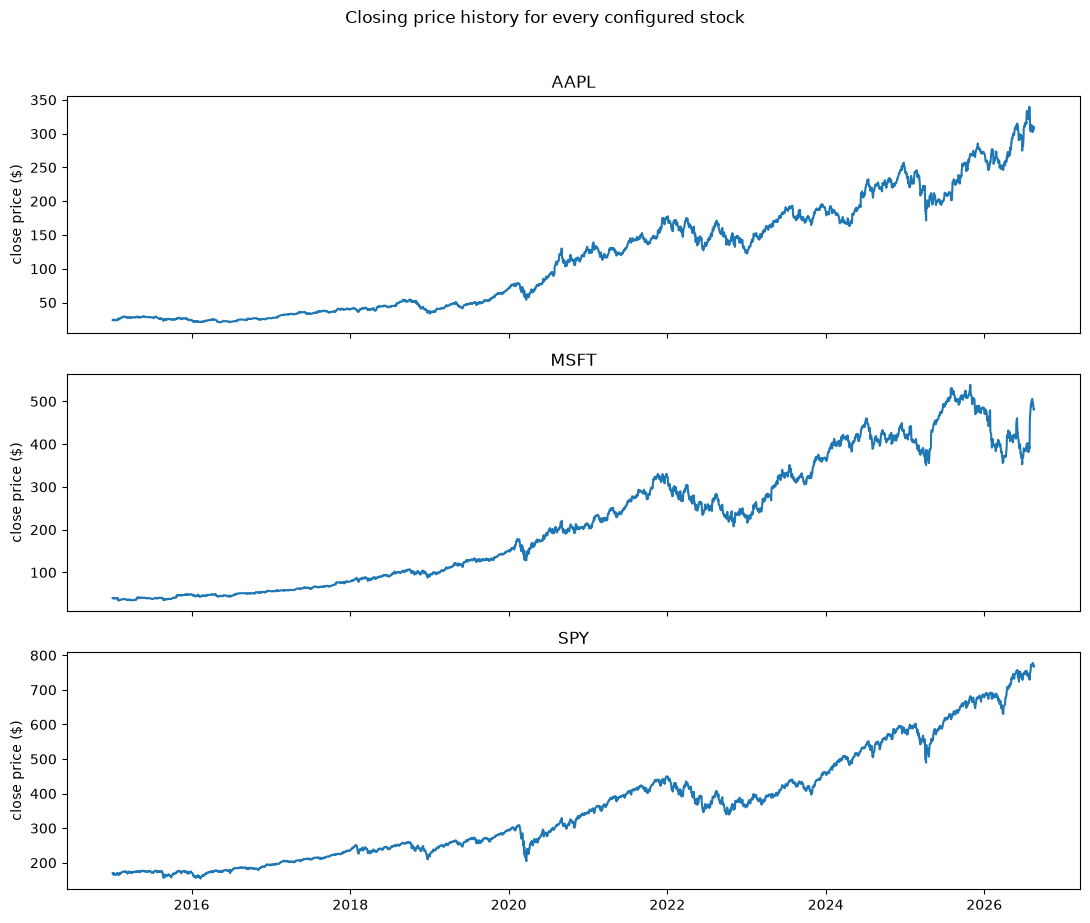

In [2]:
fig, axes = plt.subplots(len(prices), 1, figsize=(11, 3 * len(prices)), sharex=True)
for ax, (ticker, tdf) in zip(axes, prices.items(), strict=True):
    ax.plot(tdf.index, tdf["close"])
    ax.set_title(ticker)
    ax.set_ylabel("close price ($)")
fig.suptitle("Closing price history for every configured stock", y=1.02)
fig.tight_layout()
plt.show()

## 2. The features ("clues")

For our main stock (AAPL), here's what each feature actually looks like plotted against price. This is a good sanity check: does a feature move the way we'd expect it to?

- **returns_1d** — how much the price moved vs. the previous day (as a %). Should be small and jittery.
- **volatility_20d** — how choppy the last 20 days have been. Should spike during turbulent periods.
- **momentum_10d** — the 10-day return. Should track the slope of the price chart.
- **sma_ratio** — is the short-term average price above the long-term average? Positive during uptrends, negative during downtrends.

In [3]:
features = build_features(df)
features.tail()

,returns_1d,volatility_20d,momentum_10d,sma_ratio
date,,,,
2026-08-12 00:00:00-04:00,-0.008724,0.021766,-0.105501,0.004255
2026-08-13 00:00:00-04:00,0.009959,0.021437,-0.083696,-0.004139
2026-08-14 00:00:00-04:00,0.002195,0.021448,-0.008793,-0.004755
2026-08-17 00:00:00-04:00,-0.001111,0.021061,0.008020,-0.003622
2026-08-18 00:00:00-04:00,0.014529,0.021383,0.002965,-0.003516


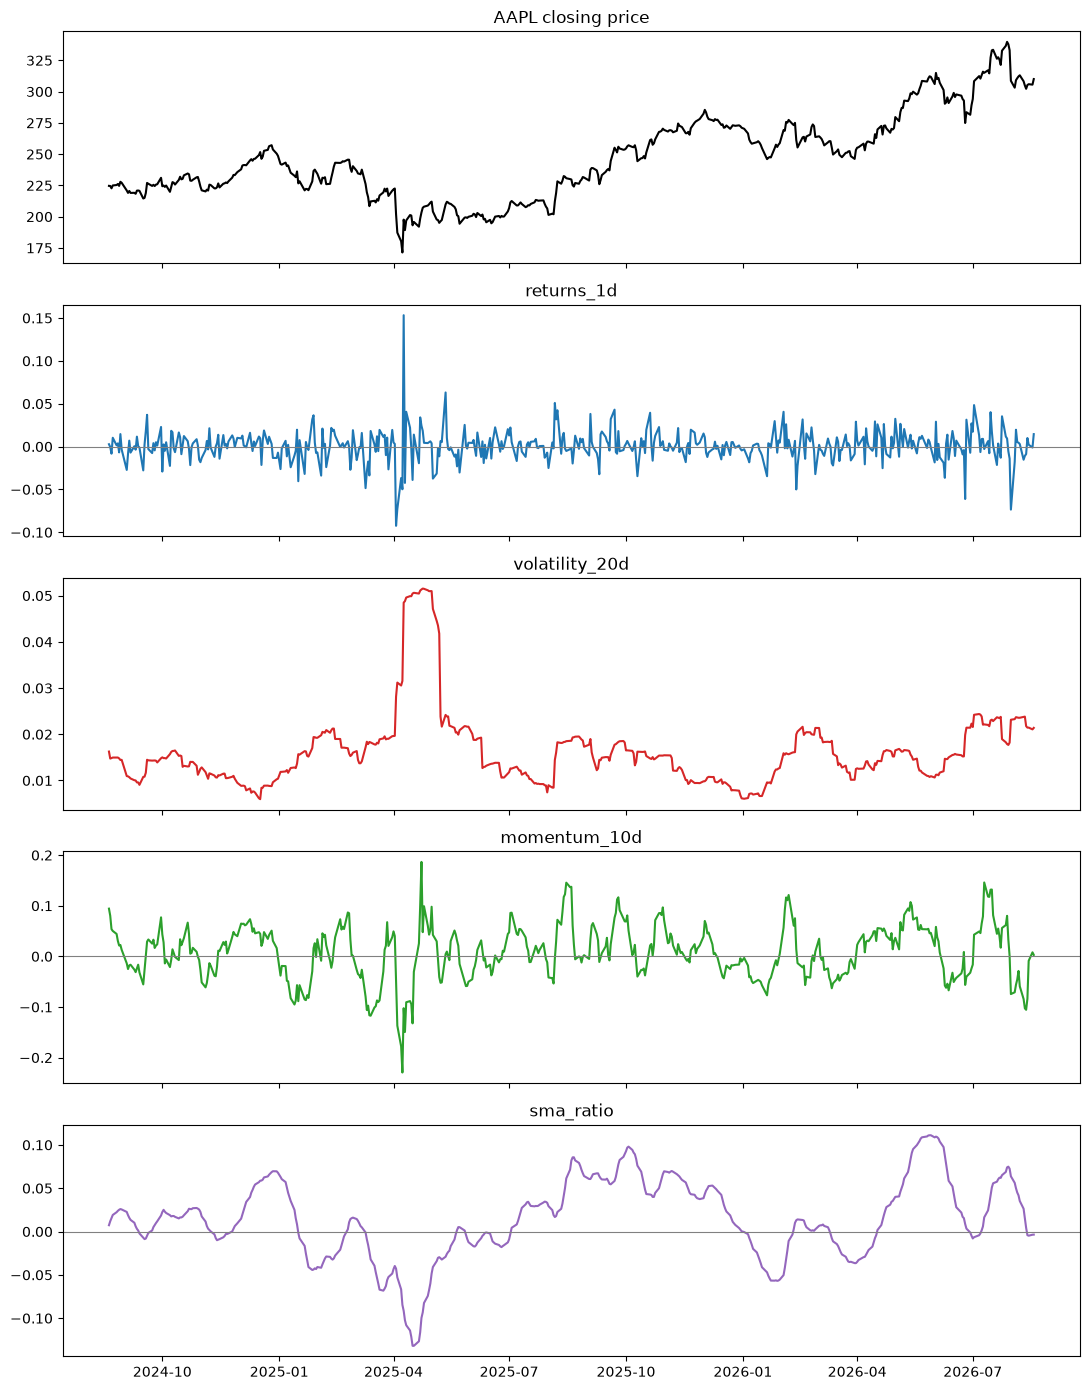

In [4]:
# Zoom in on the last ~2 years so the chart isn't too cluttered.
recent_df = df.tail(500)
recent_features = features.tail(500)

fig, axes = plt.subplots(5, 1, figsize=(11, 14), sharex=True)

axes[0].plot(recent_df.index, recent_df["close"], color="black")
axes[0].set_title(f"{TICKER} closing price")

axes[1].plot(recent_features.index, recent_features["returns_1d"])
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].set_title("returns_1d")

axes[2].plot(recent_features.index, recent_features["volatility_20d"], color="tab:red")
axes[2].set_title("volatility_20d")

axes[3].plot(recent_features.index, recent_features["momentum_10d"], color="tab:green")
axes[3].axhline(0, color="grey", linewidth=0.8)
axes[3].set_title("momentum_10d")

axes[4].plot(recent_features.index, recent_features["sma_ratio"], color="tab:purple")
axes[4].axhline(0, color="grey", linewidth=0.8)
axes[4].set_title("sma_ratio")

fig.tight_layout()
plt.show()

## 3. The final training dataset

This is what the model will actually see: the four features, plus a `target` column (tomorrow's return — what we're trying to predict). Notice the dataset is *shorter* than the raw price data: the first ~49 rows are dropped (not enough history yet to compute the slower-moving features) and the last row is dropped (there's no "tomorrow" to compute a target for on the most recent day).

In [5]:
dataset = build_dataset(df, horizon=1)
print(f"raw price rows:  {len(df)}")
print(f"dataset rows:    {len(dataset)}  (after dropping warmup + no-future-data rows)")
dataset.head()

raw price rows:  2923
dataset rows:    2873  (after dropping warmup + no-future-data rows)


,returns_1d,volatility_20d,momentum_10d,sma_ratio,target
date,,,,,
2015-03-16 00:00:00-04:00,0.011004,0.013712,-0.032071,0.052928,0.016727
2015-03-17 00:00:00-04:00,0.016727,0.014193,-0.017935,0.047804,0.011257
2015-03-18 00:00:00-04:00,0.011257,0.014339,-0.000545,0.043801,-0.007551
2015-03-19 00:00:00-04:00,-0.007551,0.014433,0.008623,0.040959,-0.012549
2015-03-20 00:00:00-04:00,-0.012549,0.014538,-0.005529,0.037187,0.010405


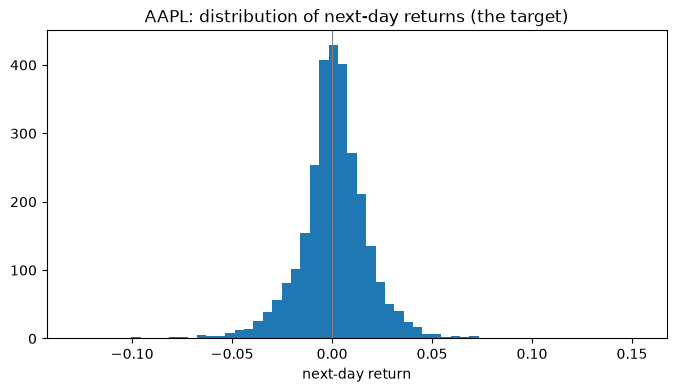

average next-day return: 0.1005%
  % of days price went up: 52.9%


In [6]:
# What does "tomorrow's return" actually look like as a distribution?
# Should be centered near zero, roughly bell-shaped, most days small moves,
# occasional larger swings in the tails.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dataset["target"], bins=60)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title(f"{TICKER}: distribution of next-day returns (the target)")
ax.set_xlabel("next-day return")
plt.show()

print(f"average next-day return: {dataset['target'].mean():.4%}")
print(f"  % of days price went up: {(dataset['target'] > 0).mean():.1%}")